# Sinogram-domain INR — projection denoising (full-angle + Poisson noise)

Fits an implicit neural representation **directly in projection/sinogram space** (no forward model, no tomographic reconstruction): a coordinate field over `(theta, s, v, t)` decoded to a line integral `p_hat`, trained with a count-space **Poisson NLL**. Package: `sdate.sino_hexplane`.

**Encoding (important):** the field now uses a **fully-joint multi-resolution hash grid** (`encoding='joint'`, spec §4). The original pairwise **HexPlane** factorisation (`encoding='hexplane'`, still available) is elegant/interpretable but empirically **could not fit sinograms** — it plateaus ~15 dB below the joint grid *even on noise-free data* and is non-monotonic in capacity. The joint grid uses **anisotropic resolution as the regulariser**: fine θ/s/v (fit detail), coarse `t` (share structure across frames = temporal-redundancy prior), with spatial resolution dose-matched.

**v1 setup (see `project-sino-hexplane` memory):**
- Synthetic data reuses the `212_Wunderkerze2` phantom + ASTRA projector of `sdate.tr_naf`, with an **advancing wedge**: frame 0 → `[0,180)`, frame 1 → `[180,360)`, … so `theta` spans the full 2π turn and advances *with* t (like continuous GigaFrost). Each frame measures only its own half-turn.
- Interesting dose regimes: `I0` (photons) ~ **1e3 / 5e2**.
- Axis convention (confirmed empirically): projection tensor `(A,R,C)` = `(angles, v, s)` — rows `R = v` (rotation axis), cols `C = s` (sinogram axis).
- Metrics scored in **line-integral / attenuation space** (`p_hat` vs clean noise-free `p`).

In [10]:
import sys
for p in ('/myhome/sdate', '/myhome/astra-torch', '/myhome/chip-project'):
    if p not in sys.path: sys.path.insert(0, p)
import numpy as np, torch
import matplotlib.pyplot as plt

from sdate.sino_hexplane import (build_helix_noise_acquisition, HelixSinoDataset,
    train_projection_field, predict, predict_frame, evaluate_all_frames,
    reconstruct_and_evaluate, ARMS)
from sdate.tr_naf.noise import counts_to_line_integral, predict_lambda, poisson_nll

dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = '/myhome/data/sdate/shared/time_resolved/212_Wunderkerze2/timesteps/212_Wunderkerze2_rotate_04001.tif'

# --- acquisition config ---
CUBE   = 64      # volume/detector resolution
NF     = 18      # number of frames (alternating [0,180)/[180,360) half-turns)
NPROJ  = 180     # projections per frame (per half-turn)
SKIP   = 10      # timestep skip so NF frames span the motion horizon
I0     = 1e3     # photons (dose). Try 1e3 / 5e2 for the photon-starved regime.
ITERS  = 1000

# --- encoding & regularisation ---
# The field uses a fully-joint multi-resolution hash grid (encoding='joint').  The
# pairwise HexPlane factorisation could NOT fit sinograms (it plateaus ~15 dB below
# this even on noise-free data and is non-monotonic in capacity).  GRID RESOLUTION
# IS THE REGULARISER, and it is anisotropic:
#   MAX_RES : spatial/angular grid res. Match to dose: ~CUBE for clean/high dose
#             (fit detail), ~32 for I0~1e3 (lower = smoother = denoises).
#   T_MAX   : TIME grid res. Coarse t forces sharing across frames (the temporal-
#             redundancy prior). Small (2-4) strongly smooths time — great for slow
#             dynamics + denoising; raise it if the dynamics have sharp transients.
MAX_RES = 64 if I0 >= 1e4 else 32
T_MAX   = 4
JOINT   = dict(max_resolution=MAX_RES, t_max_resolution=T_MAX,
               n_levels=16, n_features=2, periodic_theta=True)

## 1. Build the helix acquisition
Each frame is a noisy full half-turn scan of the object frozen at that time; consecutive frames continue the rotation.

In [11]:
frames, meta = build_helix_noise_acquisition(
    DATA, num_frames=NF, wedge_deg=180.0, angle_advance_deg=180.0,
    num_projs_per_frame=NPROJ, cube_size=CUBE, photons=I0, timestep_skip=SKIP,
    noise_seed=0, device=dev)
ds = HelixSinoDataset(frames, device=dev)
clean = [f.clean_p for f in frames]
print(f'F,A,R,C = {ds.F},{ds.A},{ds.R},{ds.C}  scale={meta["scale"]:.4f}  I0={I0:g}')
for i in range(min(4, NF)):
    tn = frames[i].theta_norm
    print(f'  frame {i}: theta band [{tn.min()*360:.0f},{tn.max()*360:.0f}] deg   t={frames[i].t_norm:.3f}')

F,A,R,C = 18,180,64,64  scale=0.0635  I0=1000
  frame 0: theta band [0,179] deg   t=0.000
  frame 1: theta band [180,359] deg   t=0.059
  frame 2: theta band [0,179] deg   t=0.118
  frame 3: theta band [180,359] deg   t=0.176


## 2. Train the projection field
Poisson NLL in count space: `p_hat -> lambda_hat = I0*exp(-p_hat)` compared to the measured counts. The encoding is the joint hash grid configured by `JOINT` above (`encoding='joint'`).

[    0/1000] poisson_nll=-502.3431  (0.1s)
[  500/1000] poisson_nll=-991.7010  (14.7s)
[  999/1000] poisson_nll=-981.9799  (28.9s)
ProjectionField [joint]: 8.77M encoding params
JointHash 5D (periodic theta) levels=16 finest[cos,sin,s,v,t]=31x31x31x31x4 (10 dense/6 hash)


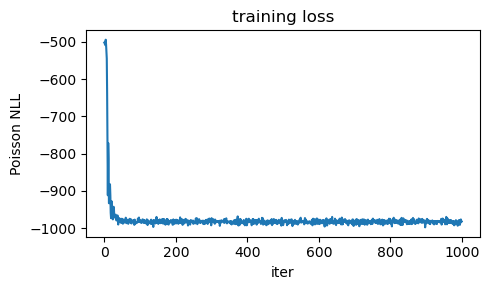

In [12]:
res = train_projection_field(ds, meta, encoding='joint', joint_kwargs=JOINT,
                             n_iters=ITERS, batch_size=32768, lr=1e-2, log_every=500)
model = res['model']
print(model.describe())
plt.figure(figsize=(5,3)); plt.plot(res['losses']); plt.xlabel('iter'); plt.ylabel('Poisson NLL')
plt.title('training loss'); plt.tight_layout(); plt.show()

## 3. Metrics: predicted vs clean projections (line-integral space)

mean PSNR 38.18 dB   mean SSIM 0.967
held-batch count-space Poisson NLL: -985.468


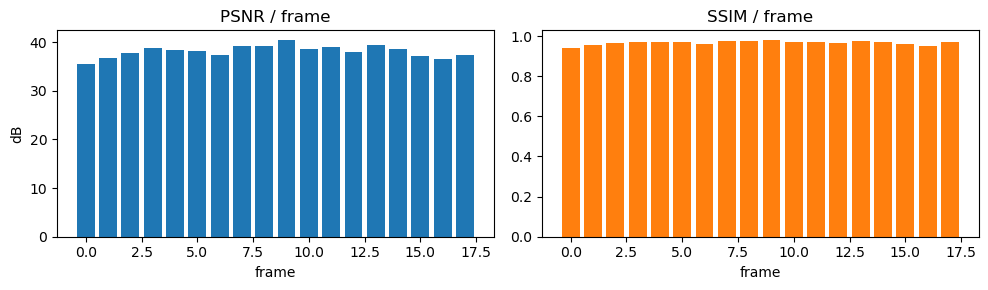

In [13]:
pred = [predict_frame(model, ds, i) for i in range(ds.F)]
mets = evaluate_all_frames(pred, clean)
print(f'mean PSNR {mets["psnr"].mean():.2f} dB   mean SSIM {mets["ssim"].mean():.3f}')
with torch.no_grad():
    b = ds.sample(200000)
    lam = predict_lambda(model(b['theta'],b['s'],b['v'],b['t']), float(meta['photons']))
    print(f'held-batch count-space Poisson NLL: {float(poisson_nll(lam, b["counts"])):.3f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].bar(range(ds.F), mets['psnr']); ax[0].set_title('PSNR / frame'); ax[0].set_xlabel('frame'); ax[0].set_ylabel('dB')
ax[1].bar(range(ds.F), mets['ssim'], color='C1'); ax[1].set_title('SSIM / frame'); ax[1].set_xlabel('frame')
plt.tight_layout(); plt.show()

## 4. Predicted vs clean projections (visual)
A single radiograph `(R=v x C=s)` and the sinogram `(theta x s)` at a fixed detector row.

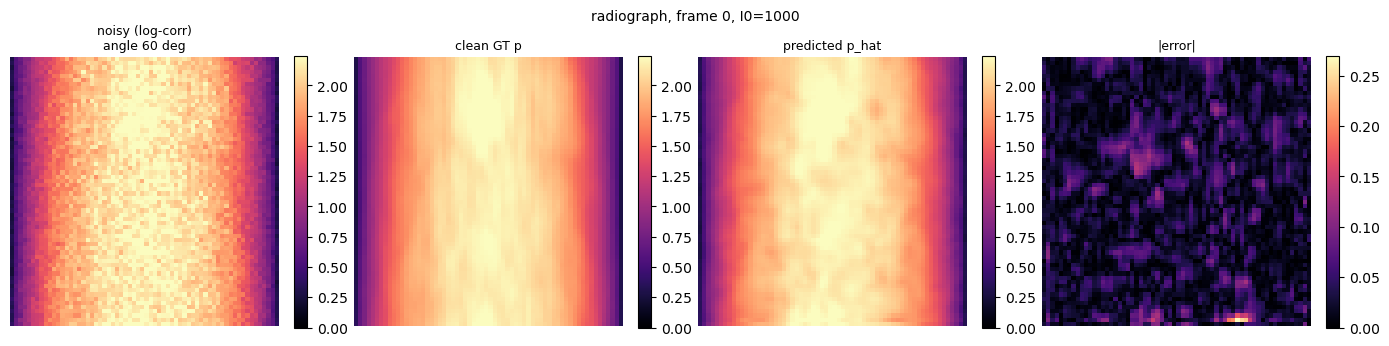

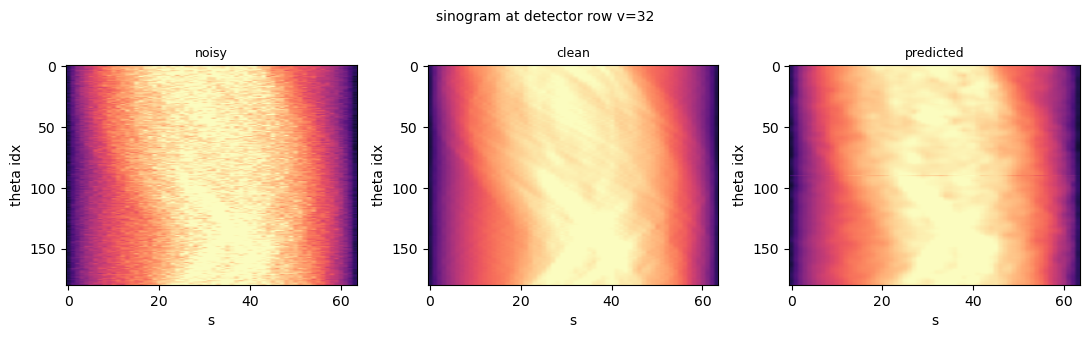

In [14]:
fi = 0
flat = meta['flat'].to(dev)
noisy_p = counts_to_line_integral(frames[fi].counts, flat, dark=meta['dark'])
dr = mets['data_range']
a = ds.A // 3
fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
panels = [(noisy_p[a], f'noisy (log-corr)\nangle {frames[fi].angles_deg[a]:.0f} deg'),
          (clean[fi][a], 'clean GT p'), (pred[fi][a], 'predicted p_hat'),
          ((pred[fi][a]-clean[fi][a]).abs(), '|error|')]
for k,(img,ttl) in enumerate(panels):
    im=ax[k].imshow(img.cpu(), cmap='magma', vmin=0, vmax=(dr if k<3 else None))
    ax[k].set_title(ttl, fontsize=9); ax[k].axis('off'); plt.colorbar(im,ax=ax[k],fraction=0.046)
plt.suptitle(f'radiograph, frame {fi}, I0={I0:g}', fontsize=10); plt.tight_layout(); plt.show()

vrow = ds.R // 2
fig, ax = plt.subplots(1, 3, figsize=(11, 3.4))
for k,(img,ttl) in enumerate([(noisy_p[:,vrow,:],'noisy'),(clean[fi][:,vrow,:],'clean'),(pred[fi][:,vrow,:],'predicted')]):
    im=ax[k].imshow(img.cpu(), aspect='auto', cmap='magma', vmin=0, vmax=dr)
    ax[k].set_title(ttl,fontsize=9); ax[k].set_xlabel('s'); ax[k].set_ylabel('theta idx')
plt.suptitle(f'sinogram at detector row v={vrow}', fontsize=10); plt.tight_layout(); plt.show()

### Interactive projection browser + movie export
Slide over the projections (angle index) of any frame, comparing noisy / clean / predicted. The last cell exports the sweep as a movie (HEVC `.mov` like `tr_naf_metrics`; falls back to `.gif` if ffmpeg/libx265 is not on PATH).

In [15]:
import ipywidgets as widgets
from ipywidgets import interact

def _noisy_sino(fi):
    return counts_to_line_integral(frames[fi].counts, flat, dark=meta['dark'])

def browse_projection(frame=0, projection=0):
    fi = int(frame); a = min(int(projection), ds.A - 1)
    npy = _noisy_sino(fi)
    fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
    for k, (img, ttl) in enumerate([(npy[a], 'noisy'), (clean[fi][a], 'clean'), (pred[fi][a], 'predicted')]):
        ax[k].imshow(img.cpu(), cmap='magma', vmin=0, vmax=dr)
        ax[k].set_title(f'{ttl}   (θ={frames[fi].angles_deg[a]:.0f}°)', fontsize=9); ax[k].axis('off')
    plt.suptitle(f'frame {fi}  ·  projection {a}/{ds.A - 1}', fontsize=10); plt.tight_layout(); plt.show()

interact(browse_projection,
         frame=widgets.Dropdown(options=list(range(ds.F)), value=0, description='frame'),
         projection=widgets.IntSlider(min=0, max=ds.A - 1, step=1, value=0, description='projection'));

interactive(children=(Dropdown(description='frame', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,…

In [16]:
# Export the projection sweep of one frame as a movie (noisy | clean | predicted, over angle).
from pathlib import Path
from sdate.sino_hexplane import generate_projection_movie

MOVIE_FRAME = 0
panels = [('noisy', _noisy_sino(MOVIE_FRAME)), ('clean', clean[MOVIE_FRAME]), ('predicted', pred[MOVIE_FRAME])]
movie_path = generate_projection_movie(
    Path('checkpoints/sino_hexplane/movies') / f'proj_frame{MOVIE_FRAME}',
    panels, fps=8, vmax=dr)
print('projection movie ->', movie_path)

[HEVC unavailable] RuntimeError: ffmpeg executable not found -> writing GIF fallback
wrote GIF checkpoints/sino_hexplane/movies/proj_frame0_noisy-clean-predicted.gif  (180 frames, panels [noisy-clean-predicted])
projection movie -> checkpoints/sino_hexplane/movies/proj_frame0_noisy-clean-predicted.gif


## 5. Interpolating theta: generating unseen projections
Fix one frame's time `t` and sweep `theta` over the **full turn**, including the half-turn that frame never measured (below the cyan line). We forward-project the frame's true volume for a ground-truth comparison — the model has *not* seen those angles at this time, so the unseen band is genuine synthesis (qualitative goal; PSNR reported for reference).

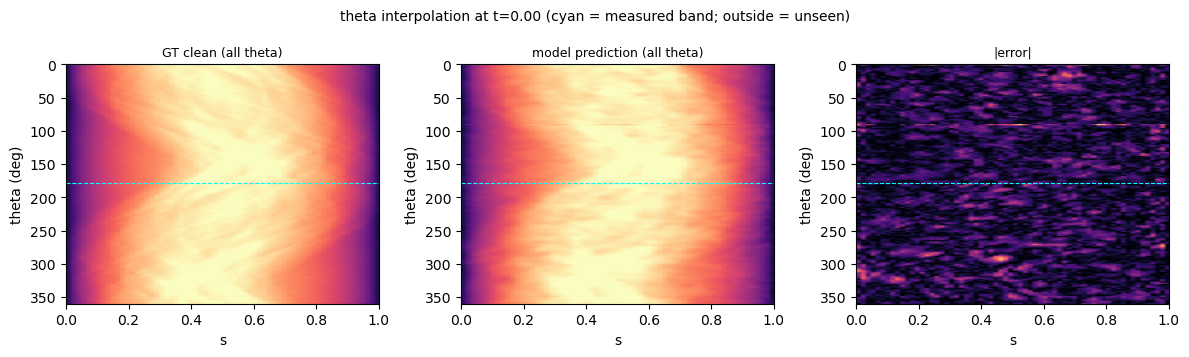

  measured band   : PSNR 35.77 dB (90 angles)
  unseen half-turn: PSNR 35.42 dB (90 angles)


In [17]:
from astra_torch.lamino import build_lamino_projector
def gt_projection(volume, thetas_deg, vrow):
    proj = build_lamino_projector(vol_shape=meta['vol_shape'], det_shape=meta['det_shape'],
        angles_deg=np.asarray(thetas_deg), lamino_angle_deg=meta['lamino_angle_deg'],
        det_spacing_mm=meta['det_spacing_mm'], device=dev)
    with torch.no_grad():
        s = proj(volume.unsqueeze(0).unsqueeze(0)).squeeze(0)
    return (s[:, vrow, :] * meta['scale']).cpu()

fi = 0
thetas_deg = np.linspace(0, 360, 180, endpoint=False)
thetas_norm = (thetas_deg % 360)/360.0
coords,(nth,C) = ds.interp_plane_coords(frames[fi].t_norm, ds.R//2, thetas_norm)
p_interp = predict(model, coords).reshape(nth, C).cpu()
gt_full  = gt_projection(frames[fi].true_volume, thetas_deg, ds.R//2)
lo, hi = frames[fi].theta_norm.min(), frames[fi].theta_norm.max()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for k,(img,ttl) in enumerate([(gt_full,'GT clean (all theta)'),(p_interp,'model prediction (all theta)'),
                               ((p_interp-gt_full).abs(),'|error|')]):
    im=ax[k].imshow(img, aspect='auto', cmap='magma', vmin=0, vmax=(dr if k<2 else None), extent=[0,1,360,0])
    ax[k].set_title(ttl,fontsize=9); ax[k].set_xlabel('s'); ax[k].set_ylabel('theta (deg)')
    ax[k].axhline(lo*360, color='cyan', lw=0.8, ls='--'); ax[k].axhline(hi*360, color='cyan', lw=0.8, ls='--')
plt.suptitle(f'theta interpolation at t={frames[fi].t_norm:.2f} (cyan = measured band; outside = unseen)', fontsize=10)
plt.tight_layout(); plt.show()

m_mask = (thetas_norm>=lo)&(thetas_norm<=hi)
for lbl,msk in [('measured band', m_mask),('unseen half-turn', ~m_mask)]:
    if msk.sum()>0:
        mse=((p_interp[msk]-gt_full[msk])**2).mean()
        print(f'  {lbl:16s}: PSNR {float(10*torch.log10(torch.tensor(dr**2)/mse)):.2f} dB ({int(msk.sum())} angles)')

## 6. Final test — GD volume reconstruction from the denoised projections

Feed each projection set into a **gradient-descent reconstruction** with a differentiable ASTRA forward model (`gd_reconstruction_masked` — the parallel-beam analog of the SAXS GD reconstruction: Adam on `min ||A·mu - p||^2`, positivity `mu>=0`, **no volume regularisation** so the recon reflects only projection quality). Each frame is a complete 180° half-turn of a frozen object, so frames reconstruct independently; the recovered `mu` is compared to `true_volume` with circular-masked PSNR/SSIM.

Four arms, identical GD settings:
- **noisy** — classical log-corrected counts `p = -ln((N-dark)/I0)` — *baseline*
- **denoised** — the model's `p_hat` at the measured angles — *the test*
- **clean** — noise-free `p` — *reconstruction-operator ceiling*
- **denoised360** — measured half-turn + the model's *synthesised* complementary half-turn (a full 360° set) — *interpolation-augmented bonus*

> Note: unregularised GD run to convergence amplifies noise, so the **noisy** arm is a deliberately un-helped floor; the informative quantities are *denoised vs noisy* (what denoising buys) and *denoised vs clean* (residual gap). Reconstruction is the slow step, so only a couple of frames are reconstructed here — raise `RECON_FRAMES` to cover more.

reconstructed frames [0, 9]  (shared data_range 0.584)

arm            PSNR (dB)     SSIM  rel-err
noisy              11.11    0.251    0.302
denoised           24.09    0.667    0.068
clean              36.63    0.967    0.016
denoised360        24.77    0.702    0.063


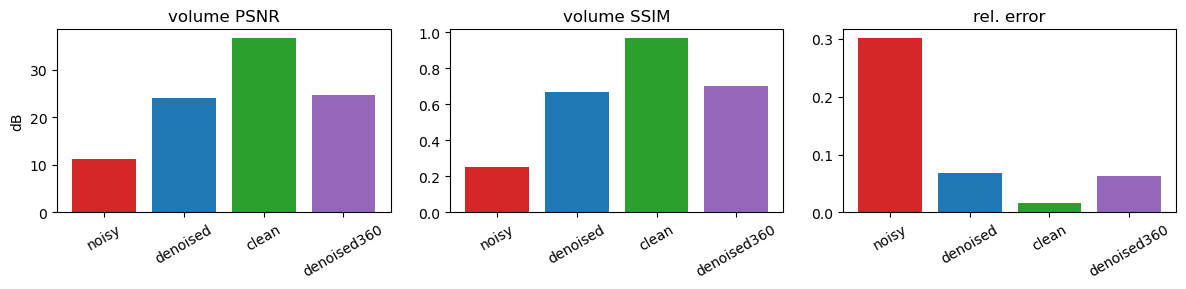

In [18]:
RECON_FRAMES = [0, ds.F // 2]     # subset (recon is the slow step); e.g. [0, ds.F//2, ds.F-1]

vols, rmets, ridx = reconstruct_and_evaluate(model, ds, frames, meta, frame_indices=RECON_FRAMES)
print(f'reconstructed frames {ridx}  (shared data_range {rmets["noisy"]["data_range"]:.3f})\n')
print(f'{"arm":13s}{"PSNR (dB)":>11s}{"SSIM":>9s}{"rel-err":>9s}')
for a in ARMS:
    m = rmets[a]
    print(f'{a:13s}{m["psnr"].mean():>11.2f}{m["ssim"].mean():>9.3f}{m["rel_err"].mean():>9.3f}')

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
labels = list(ARMS)
ax[0].bar(labels, [rmets[a]['psnr'].mean() for a in ARMS], color=['C3','C0','C2','C4'])
ax[0].set_title('volume PSNR'); ax[0].set_ylabel('dB'); ax[0].tick_params(axis='x', rotation=30)
ax[1].bar(labels, [rmets[a]['ssim'].mean() for a in ARMS], color=['C3','C0','C2','C4'])
ax[1].set_title('volume SSIM'); ax[1].tick_params(axis='x', rotation=30)
ax[2].bar(labels, [rmets[a]['rel_err'].mean() for a in ARMS], color=['C3','C0','C2','C4'])
ax[2].set_title('rel. error'); ax[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

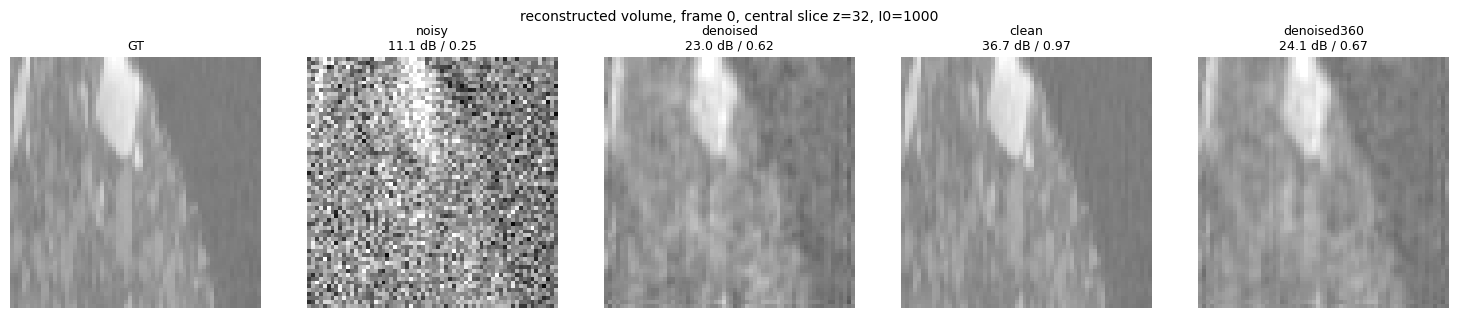

In [19]:
# Central-slice montage: GT vs each reconstructed arm (first reconstructed frame)
j = 0                                  # index into RECON_FRAMES
fi = ridx[j]
gt = frames[fi].true_volume
z = gt.shape[2] // 2
panels = [('GT', gt)] + [(a, vols[a][j]) for a in ARMS]
vmax = float(gt[..., z].max())
fig, ax = plt.subplots(1, len(panels), figsize=(3*len(panels), 3.2))
for k,(ttl,vol) in enumerate(panels):
    im = ax[k].imshow(vol[..., z].cpu(), cmap='gray', vmin=0, vmax=vmax)
    lbl = ttl if ttl=='GT' else f"{ttl}\n{rmets[ttl]['psnr'][j]:.1f} dB / {rmets[ttl]['ssim'][j]:.2f}"
    ax[k].set_title(lbl, fontsize=9); ax[k].axis('off')
plt.suptitle(f'reconstructed volume, frame {fi}, central slice z={z}, I0={I0:g}', fontsize=10)
plt.tight_layout(); plt.show()

### Interactive reconstructed-volume browser
Scroll through slices of a reconstructed volume; the **view** dropdown switches between axial (z), coronal (y) and sagittal (x). Pick the reconstruction **arm** and **frame** (from `RECON_FRAMES`); GT and the absolute error are shown alongside.

In [20]:
# Axis convention: volume is (X, Y, Z) -> axial=z(axis 2), coronal=y(axis 1), sagittal=x(axis 0).
_ORIENT = {'axial (z)': 2, 'coronal (y)': 1, 'sagittal (x)': 0}

def browse_volume(arm='denoised', frame=ridx[0], view='axial (z)', slice_index=CUBE // 2):
    j = ridx.index(int(frame)); axis = _ORIENT[view]
    vol = vols[arm][j]; gtv = frames[int(frame)].true_volume.to(vol.device)
    i = min(int(slice_index), vol.shape[axis] - 1)
    vmax = max(float(gtv.max()), 1e-8)
    gt = gtv.select(axis, i).cpu(); rec = vol.select(axis, i).cpu()
    fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
    ax[0].imshow(gt, cmap='gray', vmin=0, vmax=vmax); ax[0].set_title('GT', fontsize=9); ax[0].axis('off')
    ax[1].imshow(rec, cmap='gray', vmin=0, vmax=vmax); ax[1].set_title(arm, fontsize=9); ax[1].axis('off')
    ax[2].imshow((rec - gt).abs(), cmap='magma'); ax[2].set_title('|error|', fontsize=9); ax[2].axis('off')
    plt.suptitle(f'{view} slice {i}/{vol.shape[axis]-1}  ·  frame {frame}, I0={I0:g}', fontsize=10)
    plt.tight_layout(); plt.show()

interact(browse_volume,
         arm=widgets.Dropdown(options=list(ARMS), value='denoised', description='arm'),
         frame=widgets.Dropdown(options=ridx, value=ridx[0], description='frame'),
         view=widgets.Dropdown(options=list(_ORIENT), value='axial (z)', description='view'),
         slice_index=widgets.IntSlider(min=0, max=CUBE - 1, step=1, value=CUBE // 2, description='slice'));

interactive(children=(Dropdown(description='arm', index=1, options=('noisy', 'denoised', 'clean', 'denoised360…